# Problem statment

The objective is to develop a machine learning model that can predict the power consumption (Zone 1 Power Consumption) of Wellington, New Zealand based on various environmental and meteorological factors. The goal is to create an accurate predictive model that can assist in managing energy resources efficiently and optimizing power consumption in that zone.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#import sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ignore harmless warnings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set()

In [ ]:
#import data
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/project3/City Power Consumption.xlsx')

#data dimentions
df.shape

(52583, 9)

In [ ]:
#data columns
df.columns

Index(['S no', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Air Quality Index (PM)',
       'Cloudiness', ' Power Consumption in A Zone'],
      dtype='object')

In [ ]:
df.columns = ['S_no', 'Temperature', 'Humidity', 'Wind_Speed','gen_diffuse_flows', 'diffuse_flows', 'AQI(PM)', 'Cloudiness', 'Power_Consumption(A)']
df.columns

Index(['S_no', 'Temperature', 'Humidity', 'Wind_Speed', 'gen_diffuse_flows',
       'diffuse_flows', 'AQI(PM)', 'Cloudiness', 'Power_Consumption(A)'],
      dtype='object')

In [ ]:
#sample data
df.head()

,S_no,Temperature,Humidity,Wind_Speed,gen_diffuse_flows,diffuse_flows,AQI(PM),Cloudiness,Power_Consumption(A)
0,1,6.559,73.8,0.083,0.051,0.119,158.0,1,34055.69620
1,2,6.414,74.5,0.083,0.070,0.085,159.0,1,29814.68354
2,3,6.313,74.5,0.080,0.062,0.100,151.0,1,29128.10127
3,4,6.121,75,0.083,0.091,0.096,151.0,1,28228.86076
4,5,5.921,75.7,0.081,0.048,0.085,154.0,1,27335.69620


## Data Preprocessing and Cleaning

In [ ]:
#remove id column
del df['S_no']

In [ ]:
#check duplicated data
print(f'Dataset have {df.duplicated().sum()} duplicate records.')

Dataset have 0 duplicate records.


In [ ]:
#check datatype
pd.concat([df.dtypes,df.head().T],axis=1)

,0,0,1,2,3,4
Temperature,object,6.559,6.414,6.313,6.121,5.921
Humidity,object,73.8,74.5,74.5,75,75.7
Wind_Speed,float64,0.083,0.083,0.08,0.083,0.081
gen_diffuse_flows,float64,0.051,0.07,0.062,0.091,0.048
diffuse_flows,float64,0.119,0.085,0.1,0.096,0.085
AQI(PM),float64,158.0,159.0,151.0,151.0,154.0
Cloudiness,int64,1,1,1,1,1
Power_Consumption(A),float64,34055.6962,29814.68354,29128.10127,28228.86076,27335.6962


### Observation:
1. Column Temperature and Humidity have mismatch datatype

In [ ]:
#changing Temperature and Humidity to its original datatype
df['Temperature'] = pd.to_numeric(df['Temperature'],errors='coerce')  #'coerce'=> then invalid parsing will be set as NaN
df['Humidity'] = pd.to_numeric(df['Humidity'],errors='coerce')

#check datatype after handling mismatch datatype
pd.concat([df.dtypes,df.head().T],axis=1)

,0,0,1,2,3,4
Temperature,float64,6.5590,6.41400,6.31300,6.12100,5.9210
Humidity,float64,73.8000,74.50000,74.50000,75.00000,75.7000
Wind_Speed,float64,0.0830,0.08300,0.08000,0.08300,0.0810
gen_diffuse_flows,float64,0.0510,0.07000,0.06200,0.09100,0.0480
diffuse_flows,float64,0.1190,0.08500,0.10000,0.09600,0.0850
AQI(PM),float64,158.0000,159.00000,151.00000,151.00000,154.0000
Cloudiness,int64,1.0000,1.00000,1.00000,1.00000,1.0000
Power_Consumption(A),float64,34055.6962,29814.68354,29128.10127,28228.86076,27335.6962


In [ ]:
#Check null values
round(df.isna().sum()/len(df)*100,2)

,0
Temperature,0.61
Humidity,0.05
Wind_Speed,0.14
gen_diffuse_flows,0.59
diffuse_flows,0.03
AQI(PM),0.03
Cloudiness,0.00
Power_Consumption(A),0.00


### Observation
1. Less than 1 percentage of missing data in 6 columns; We can drop them

In [ ]:
#data shape before drop
print('Data dimension before drop:',df.shape)

#drop missing data
df.dropna(axis=0,inplace=True)

#data shape after drop
print('Data dimension after drop:',df.shape)

Data dimension before drop: (52583, 8)
Data dimension after drop: (52143, 8)


## Exploratory Data analysis (EDA) and Feature scalling

* All data are numerical data type except Cloudiness and AQI.

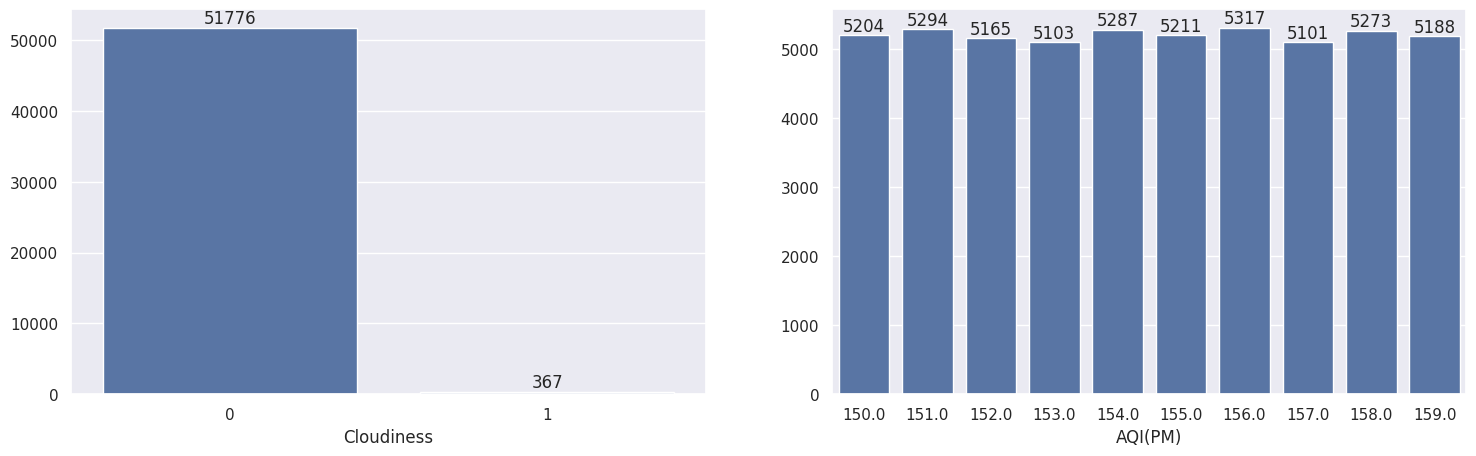

In [ ]:
#categorical feature
i=1
plt.figure(figsize=(18,5))
for col in ['Cloudiness','AQI(PM)']:
  plt.subplot(1,2,i)
  ax = sns.barplot(x=df[col].value_counts().index, y=df[col].value_counts().values)
  ax.bar_label(ax.containers[0])
  i += 1

plt.show()


### Observation

* In Cloudiness feature 99.3% of data belogs to 0 and 0.7% data belogs to 1
* Cloudiness does not provide any significance to our output
* We can drop Cloudiness feature

In [ ]:
#numerical Features
num_df = df.drop(['Cloudiness','AQI(PM)'],axis=1)
num_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,52143.0,18.841426,5.810140,3.24700,14.43000,18.84000,22.92000,40.01000
Humidity,52143.0,68.237918,15.571206,11.34000,58.27000,69.85000,81.40000,94.80000
Wind_Speed,52143.0,1.968506,2.350854,0.05000,0.07800,0.08600,4.91500,6.48300
gen_diffuse_flows,52143.0,182.868973,264.760374,0.00400,0.06200,4.99800,319.65000,1163.00000
diffuse_flows,52143.0,75.197962,124.434827,0.01100,0.12200,4.41300,101.30000,936.00000
Power_Consumption(A),52143.0,31112.707495,8007.743843,9457.75076,24804.65869,31236.19672,36763.07692,52204.39512


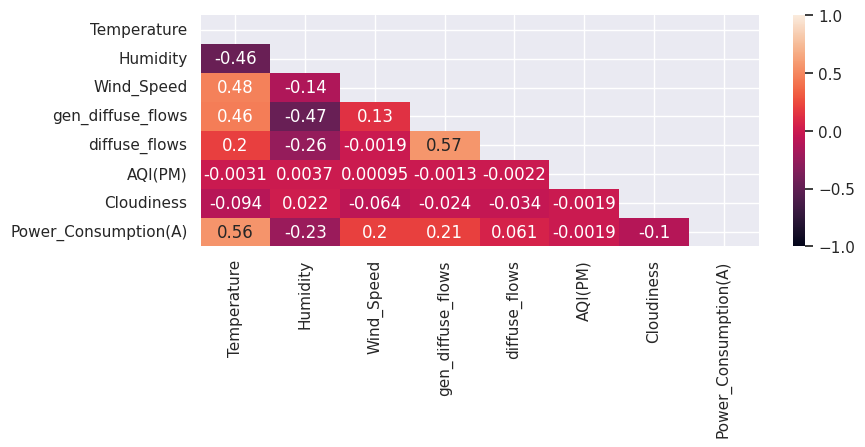

In [ ]:
# plot heatmap to understand correlation
plt.figure(figsize=(9,3))
sns.heatmap(df.corr(),vmin=-1,vmax=1,annot=True,mask=np.triu(df.corr()))
plt.show()

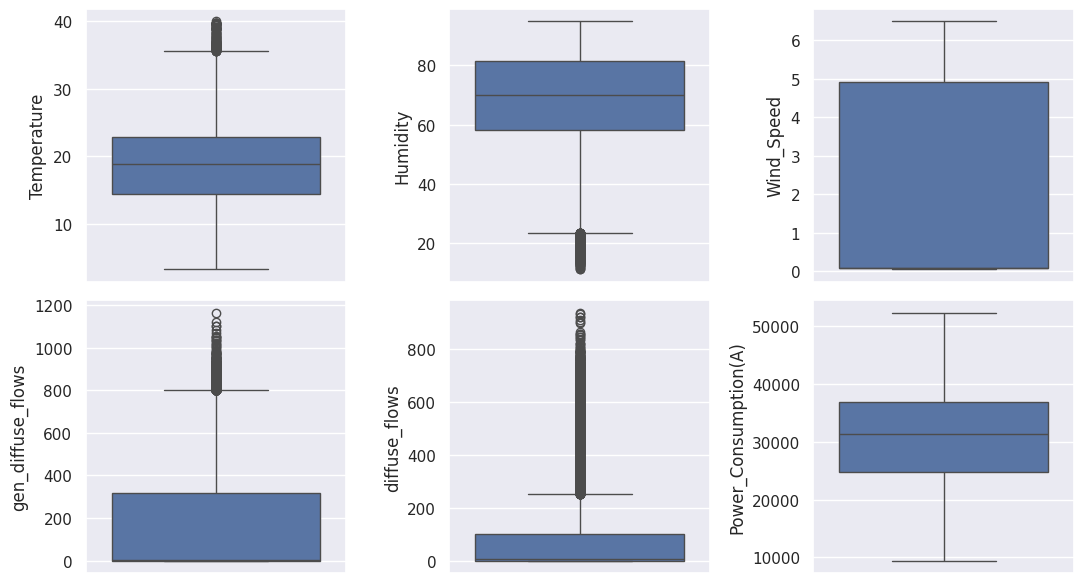

In [ ]:
#bar plot to check outliers
c = 1
plt.figure(figsize=(11,6))
for col in num_df.columns:
    plt.subplot(2,3,c)
    sns.boxplot(y=df[col])
    c +=1

plt.tight_layout()
plt.show()



### Observation
1. Temperature, Humidity, gen_diffuse_flows and diffuse_flows features have outliers

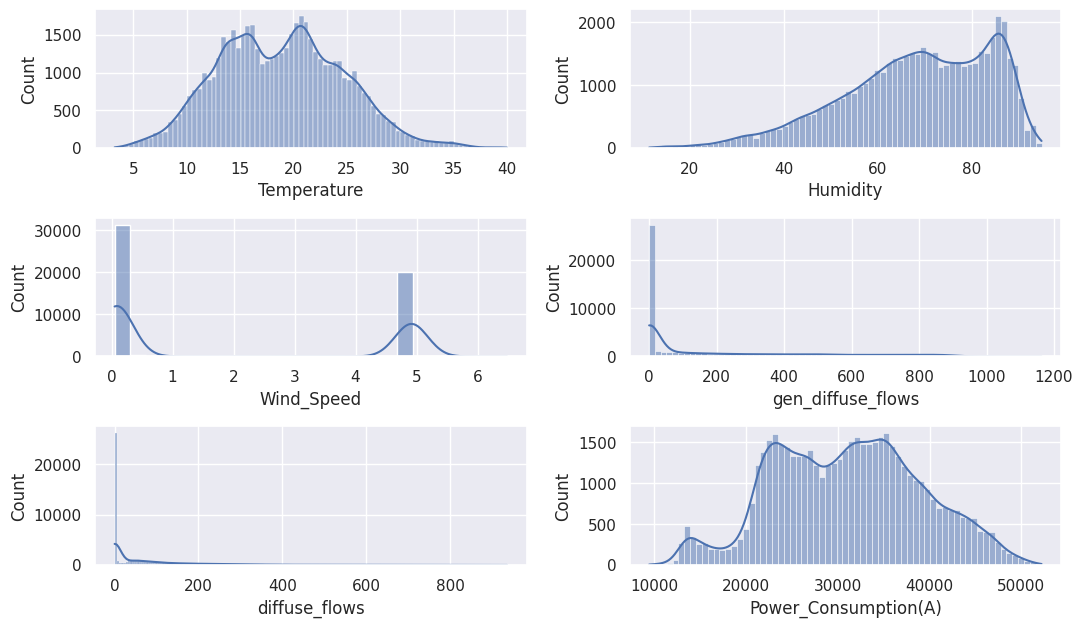

In [ ]:
# hist plot
c = 1
plt.figure(figsize=(11,8))
for col in num_df.columns:
    plt.subplot(4,2,c)
    sns.histplot(x=df[col],kde=True)
    c +=1

plt.tight_layout()
plt.show()

In [ ]:
# outlier treatment using IQR method

for col in ['Temperature', 'Humidity', 'gen_diffuse_flows', 'diffuse_flows']:
    Q1 = np.quantile(df[col],0.25)
    Q3 = np.quantile(df[col],0.75)
    IQR = Q3 - Q1
    LL = Q1 - 1.5 * IQR
    UL = Q3 + 1.5 * IQR
    df[col] = np.where(df[col]<LL,LL,np.where(df[col]>UL, UL, df[col]))



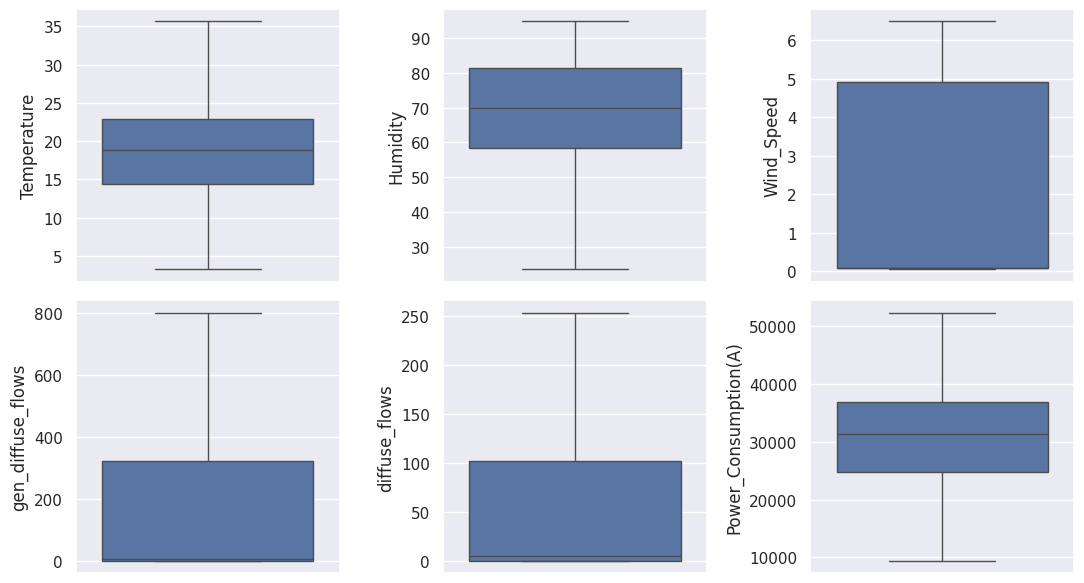

In [ ]:
#bar plot after outliers treatment
c = 1
plt.figure(figsize=(11,6))
for col in num_df.columns:
    plt.subplot(2,3,c)
    sns.boxplot(y=df[col])
    c +=1

plt.tight_layout()
plt.show()



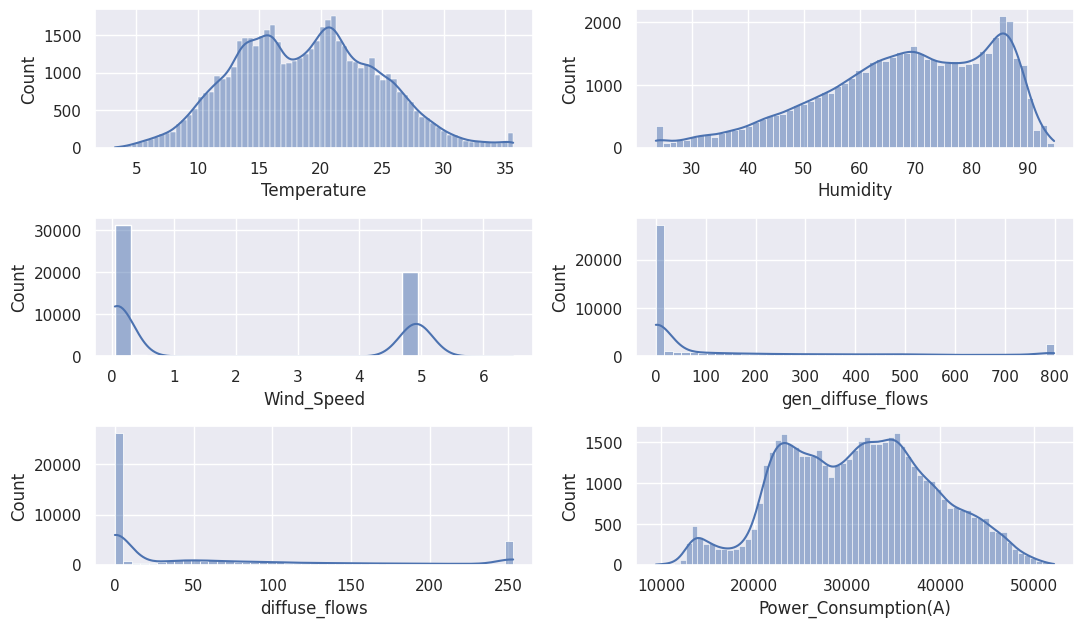

In [ ]:
# hist plot after outlier treatment
c = 1
plt.figure(figsize=(11,8))
for col in num_df.columns:
    plt.subplot(4,2,c)
    sns.histplot(x=df[col],kde=True)
    c +=1

plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['Temperature', 'Humidity', 'Wind_Speed', 'gen_diffuse_flows',
       'diffuse_flows', 'AQI(PM)', 'Cloudiness', 'Power_Consumption(A)'],
      dtype='object')

In [ ]:
# train test split

train, test = train_test_split(df,test_size=0.2,random_state=42)

#train test dimensions
print('train',train.shape)
print('test',test.shape)

train (41714, 8)
test (10429, 8)


In [ ]:
# train data scaling
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train)
train_scaled_df = pd.DataFrame(train_scaled, columns=scaler.get_feature_names_out(), index=train.index) #to make sure index does not reset
train_scaled_df.head()

,Temperature,Humidity,Wind_Speed,gen_diffuse_flows,diffuse_flows,AQI(PM),Cloudiness,Power_Consumption(A)
33585,0.789755,-0.713951,1.257974,-0.694742,-0.728194,-1.569832,-0.083816,-0.771017
18347,0.307140,-0.106279,-0.801801,1.818587,2.244147,-0.175718,-0.083816,0.231261
27981,0.877975,0.859914,1.254570,-0.472617,-0.210924,-1.221304,-0.083816,-0.628892
3651,-2.175822,0.950514,-0.798822,-0.661377,-0.629332,-0.524247,-0.083816,-1.836788
18607,-0.549114,1.409989,1.255421,-0.694882,-0.727924,0.869868,-0.083816,-1.206389


In [ ]:
# test data scaling

test_scaled = scaler.transform(test)
test_scaled_df = pd.DataFrame(test_scaled, columns=scaler.get_feature_names_out(), index=test.index)
test_scaled_df.head()

,Temperature,Humidity,Wind_Speed,gen_diffuse_flows,diffuse_flows,AQI(PM),Cloudiness,Power_Consumption(A)
50759,-1.209899,0.892271,-0.800524,0.985740,-0.071924,1.566925,-0.083816,0.152290
24925,0.037290,0.283952,1.256698,-0.694955,-0.727536,-0.872775,-0.083816,1.465150
28693,0.447254,-0.820730,1.254995,-0.683075,-0.700112,-0.175718,-0.083816,-0.726115
670,-0.102824,-1.013580,-0.797970,0.337107,1.172960,0.521339,-0.083816,-1.194733
11576,-1.491857,1.448818,-0.800098,0.730406,2.244147,1.566925,-0.083816,0.026857


In [ ]:
#dependent independent split
x_train_scaled_df = train_scaled_df.drop(['Power_Consumption(A)','Cloudiness'],axis=1)
y_train = train_scaled_df['Power_Consumption(A)']

x_test_scaled_df = test_scaled_df.drop(['Power_Consumption(A)','Cloudiness'],axis=1)
y_test = test_scaled_df['Power_Consumption(A)']

#train test dimensions
print('x_train',x_train_scaled_df.shape)
print('y_train',y_train.shape)
print('x_test',x_test_scaled_df.shape)
print('y_test',y_test.shape)

x_train (41714, 6)
y_train (41714,)
x_test (10429, 6)
y_test (10429,)


In [ ]:
#import joblib and save scaler
import joblib

joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

## Variance Inflation Factor (VIF) >5 [to check Multicollinearity]

In [ ]:
lr_data = x_train_scaled_df
lr_data = sm.add_constant(lr_data)  # adds intercept
vif = pd.DataFrame()
vif['features'] = lr_data.columns
vif['variance_inflation_factor'] = [variance_inflation_factor(lr_data,i) for i in range(lr_data.shape[1])]

vif

,features,variance_inflation_factor
0,const,1.000000
1,Temperature,1.797228
2,Humidity,1.421031
3,Wind_Speed,1.321356
4,gen_diffuse_flows,2.095068
5,diffuse_flows,1.651415
6,AQI(PM),1.000135


### Observation

* Data does not have multicollinearity

## Model Building

In [ ]:
# OLS model

lr_model = sm.OLS(y_train,lr_data)
results = lr_model.fit()
print(results.params)

const               -1.453712e-16
Temperature          6.440383e-01
Humidity             2.158194e-02
Wind_Speed          -9.570026e-02
gen_diffuse_flows   -4.725422e-02
diffuse_flows       -2.957019e-02
AQI(PM)              1.284632e-03
dtype: float64


In [ ]:
y_train_pred = results.predict(lr_data)

lr_test_data = sm.add_constant(x_test_scaled_df)
y_test_pred = results.predict(lr_test_data)
# Model metrics
ols_train_acc =  r2_score(y_train, y_train_pred)
ols_r2_score = r2_score(y_test, y_test_pred)
print('Training Accuracy:',ols_train_acc)
print('Testing Accuracy:', ols_r2_score)

Training Accuracy: 0.32313991066083303
Testing Accuracy: 0.32338040130928003


In [ ]:
print(results.summary())

                             OLS Regression Results                             
Dep. Variable:     Power_Consumption(A)   R-squared:                       0.323
Model:                              OLS   Adj. R-squared:                  0.323
Method:                   Least Squares   F-statistic:                     3319.
Date:                  Thu, 10 Jul 2025   Prob (F-statistic):               0.00
Time:                          13:21:47   Log-Likelihood:                -51049.
No. Observations:                 41714   AIC:                         1.021e+05
Df Residuals:                     41707   BIC:                         1.022e+05
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             

### Observation
* AQI(PM) have p value > 0.05

In [ ]:
#ols model after droping insignificant variable
lr_data_drp = lr_data.drop('AQI(PM)',axis=1)
lr_model_drp = sm.OLS(y_train,lr_data_drp)
results_drp = lr_model_drp.fit()
y_train_pred_drp = results_drp.predict(lr_data_drp)

lr_test_data_drp = lr_test_data.drop('AQI(PM)',axis=1)
y_test_pred_drp= results_drp.predict(lr_test_data_drp)

# Model metrics
ols_train_acc2 =  r2_score(y_train, y_train_pred_drp)
ols_r2_score2 = r2_score(y_test, y_test_pred_drp)
print('Training Accuracy:',ols_train_acc2)
print('Testing Accuracy:', ols_r2_score2)
print('Mean Square Error:', round(mean_squared_error(y_test, y_test_pred_drp), 4))
print(results_drp.summary())

Training Accuracy: 0.32313826060370365
Testing Accuracy: 0.3233981908293069
Mean Square Error: 0.6794
                             OLS Regression Results                             
Dep. Variable:     Power_Consumption(A)   R-squared:                       0.323
Model:                              OLS   Adj. R-squared:                  0.323
Method:                   Least Squares   F-statistic:                     3982.
Date:                  Thu, 10 Jul 2025   Prob (F-statistic):               0.00
Time:                          13:21:47   Log-Likelihood:                -51049.
No. Observations:                 41714   AIC:                         1.021e+05
Df Residuals:                     41708   BIC:                         1.022e+05
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--

### Observation
* Even after droping insignificant variable accuracy is not increasing.
* High chances that problem is non-linear


In [ ]:
#try ploynomial model

# Simple polynomial regression
degree = 2
poly_feature = PolynomialFeatures(degree=degree)
x_train_poly = poly_feature.fit_transform(x_train_scaled_df)
x_test_poly = poly_feature.transform(x_test_scaled_df)

# Converting the scaled data into data frame
x_train_poly_df = pd.DataFrame(x_train_poly)
x_test_poly_df = pd.DataFrame(x_test_poly)

# Linear model on polynomial data
model = LinearRegression()
model.fit(x_train_poly_df, y_train)
poly_train_acc = model.score(x_train_poly_df, y_train)
print('Training Score:',poly_train_acc)

y_pred_poly = model.predict(x_test_poly_df)
poly_test_acc= r2_score(y_test, y_pred_poly)
print('Testing Score:', poly_test_acc)
print('Mean Square Error:', round(mean_squared_error(y_test, y_pred_poly), 4))

Training Score: 0.358001633581728
Testing Score: 0.352198970220993
Mean Square Error: 0.6505


In [ ]:
# Base models
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)
svr = SVR()
rg = Ridge(random_state=42, alpha=10)
ls = Lasso(random_state=42, alpha=0.01)
lr = LinearRegression()
xgb = XGBRegressor(n_estimators=300, learning_rate=0.1, random_state=42)


# Voting Classifier (can be hard or soft)
voting = VotingRegressor(
    estimators=[
        ('DT', dt),
        ('RF', rf),
        ('SVR', svr),
        ('RG', rg),
        ('LS', ls),
        ('LR', lr),
        ('XGB', xgb)
        ]
)


models = {
    'Decision Tree': dt,
    'Random Forest': rf,
    'SVR': svr,
    'Ridge': rg,
    'Lasso': ls,
    'Linear Regression': lr,
    'XGBoost': xgb,
    'Voting': voting
}


In [ ]:
model_names = []
model_train_acc = []
model_test_acc = []
r2_acc= []
result_df = {}

for name, model in models.items():
    model.fit(x_train_scaled_df, y_train)
    train_score = model.score(x_train_scaled_df, y_train)
    y_pred = model.predict(x_test_scaled_df)

    r2 = r2_score(y_test, y_pred)
    model_names.append(name)
    model_train_acc.append(train_score)
    r2_acc.append(r2)

result_df = {
    'Model_name' : model_names,
    'Train_acc' : model_train_acc,
    'r2_score' : r2_acc
}



In [ ]:
result_df['Model_name'].extend(['OLS','POLY'])
result_df['Train_acc'].extend([ols_train_acc2,poly_train_acc])
result_df['r2_score'].extend([ols_r2_score2,poly_test_acc])

result_df_ = pd.DataFrame(result_df)

In [ ]:
result_df_.columns = ['Model_name','Train_acc','Test_acc']
result_df_

,Model_name,Train_acc,Test_acc
0,Decision Tree,1.000000,0.287621
1,Random Forest,0.946862,0.628700
2,SVR,0.367695,0.352500
3,Ridge,0.323140,0.323385
4,Lasso,0.322217,0.323058
5,Linear Regression,0.323140,0.323380
6,XGBoost,0.657684,0.557465
7,Voting,0.686836,0.516035
8,OLS,0.323138,0.323398
9,POLY,0.358002,0.352199


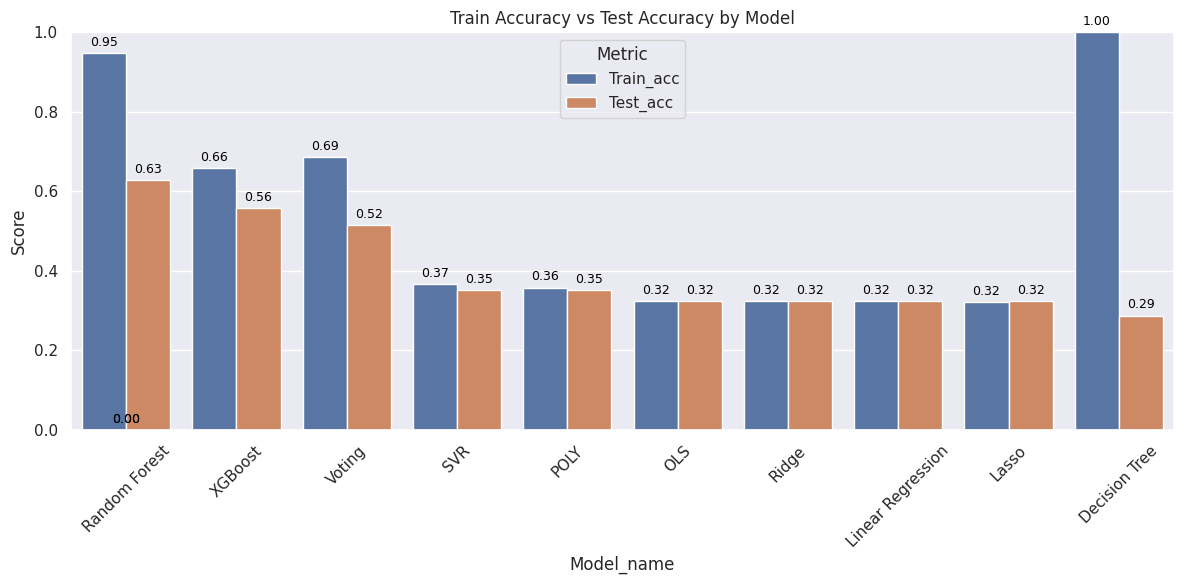

In [ ]:


# Sort by Test_acc descending
result_df_ = result_df_.sort_values(by='Test_acc', ascending=False)

# Melt to long format for Seaborn
result_melted = result_df_.melt(id_vars='Model_name',
                               value_vars=['Train_acc', 'Test_acc'],
                               var_name='Metric',
                               value_name='Score')

# Ensure plot preserves sorting order
result_melted['Model_name'] = pd.Categorical(result_melted['Model_name'],
                                              categories=result_df_['Model_name'],
                                              ordered=True)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=result_melted, x='Model_name', y='Score', hue='Metric')
plt.title('Train Accuracy vs Test Accuracy by Model')
plt.ylim(0, 1)
plt.xticks(rotation=45)

# Add bar labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.show()


### Observation
* Out of all models XGBoost giving comparitively good accuracy

In [ ]:
#xgBoost
# Create an XGBRegressor model
xg_model = XGBRegressor(n_estimators=300, learning_rate=0.1, random_state=42)

# Train the model
xg_model.fit(x_train_scaled_df, y_train)
print('Training Score:', round(xg_model.score(x_train_scaled_df, y_train)*100,2),'%')

# Make predictions on the test set
y_pred_xg = xg_model.predict(x_test_scaled_df)

print('Testing Score:', round(r2_score(y_test, y_pred_xg)*100, 2),'%')

# Evaluate the model
rmse = mean_squared_error(y_test, y_pred_xg)
print(f"Root Mean Squared Error: {rmse}")

Training Score: 65.77 %
Testing Score: 55.75 %
Root Mean Squared Error: 0.4443545507810467


## Trying ANN model

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

def build_model(hp):
    model = Sequential()
    model.add(Dense(hp.Int('units_input', min_value=32, max_value=128, step=32), activation='relu', input_shape=(x_train_scaled_df.shape[1],)))

    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(hp.Int(f'units_{i}', min_value=32, max_value=128, step=32), activation='relu'))

    model.add(Dense(1))  # Output layer for regression (no activation)
    model.compile(
        optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', [1e-3, 1e-4])),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

# # Train
# history = ann_model.fit(x_train_scaled_df, y_train, validation_split=0.2, epochs=100, batch_size=32)

# # Evaluate
# ann_model.evaluate(x_test_scaled_df, y_test)

In [ ]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.4 MB/s eta 0:00:00


In [ ]:
# importing the tuner
import keras_tuner
from kerastuner.tuners import RandomSearch
# Spining the tuner
tuner = RandomSearch(
    hypermodel=build_model,
    objective='val_mae',
    max_trials=3,
    executions_per_trial=1,
    project_name='Power_consumption'
)


In [ ]:
# tuner summary
tuner.search_space_summary()

Search space summary
Default search space size: 4
units_input (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001], 'ordered': True}


In [ ]:
# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Start search
tuner.search(x_train_scaled_df, y_train, validation_split=0.2, epochs=50, callbacks=[early_stop], verbose=1)


Trial 3 Complete [00h 01m 43s]
val_mae: 0.5914333462715149

Best val_mae So Far: 0.5866044163703918
Total elapsed time: 00h 08m 16s


In [ ]:
# results summary
tuner.results_summary()

Results summary
Results in ./Power_consumption
Showing 10 best trials
Objective(name="val_mae", direction="min")

Trial 0 summary
Hyperparameters:
units_input: 96
num_layers: 1
units_0: 96
learning_rate: 0.001
Score: 0.5866044163703918

Trial 2 summary
Hyperparameters:
units_input: 96
num_layers: 2
units_0: 96
learning_rate: 0.001
units_1: 32
Score: 0.5914333462715149

Trial 1 summary
Hyperparameters:
units_input: 128
num_layers: 1
units_0: 128
learning_rate: 0.0001
Score: 0.610885500907898


In [ ]:
# best hyperparameters

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]       # top 1 best model


In [ ]:
# build and train the model
final_model = tuner.hypermodel.build(best_hps)
es = EarlyStopping(monitor='val_loss',mode='auto',verbose=1, patience=3)
history = final_model.fit(x_train_scaled_df, y_train, initial_epoch=30, epochs=50, validation_split=0.2,callbacks=[es])

# Evaluate
final_model.evaluate(x_test_scaled_df, y_test)

Epoch 31/50
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.6815 - mae: 0.6530 - val_loss: 0.6532 - val_mae: 0.6381
Epoch 32/50
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.6229 - mae: 0.6228 - val_loss: 0.6482 - val_mae: 0.6326
Epoch 33/50
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.6191 - mae: 0.6188 - val_loss: 0.6336 - val_mae: 0.6181
Epoch 34/50
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.6173 - mae: 0.6136 - val_loss: 0.6335 - val_mae: 0.6216
Epoch 35/50
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.6039 - mae: 0.6075 - val_loss: 0.6239 - val_mae: 0.6226
Epoch 36/50
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5989 - mae: 0.6033 - val_loss: 0.6254 - val_mae: 0.6245
Epoch 37/50
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.5974 - mae: 0.6045 - val_loss: 0.6217 - val_mae: 0.6109
Epoch 38/50
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.5947 - mae: 0.6021 - val_loss: 0.6240 - val_mae: 0.6219
Epoch 39/50
1043/1043 ━━━━━━━

[0.5835088491439819, 0.5877917408943176]

In [ ]:
# Evaluate on test data
y_pred = final_model.predict(x_test_scaled_df).flatten()
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n📊 Model Evaluation on Test Data:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

📊 Model Evaluation on Test Data:
Mean Squared Error (MSE): 0.5835
Mean Absolute Error (MAE): 0.5878
R² Score: 0.4189


dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


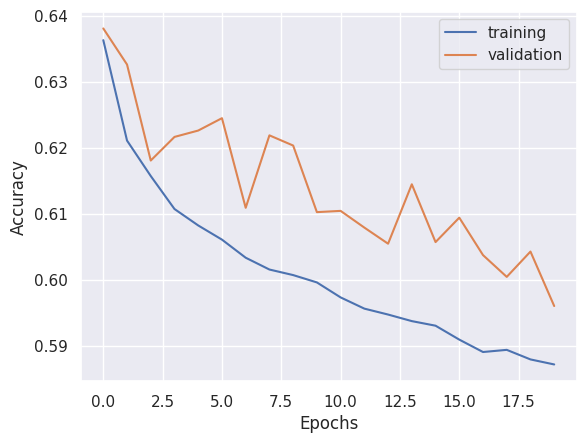

In [ ]:
# plot the accuracy vs val_accuracy
print(history.history.keys())

plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['training', 'validation'])
plt.show()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


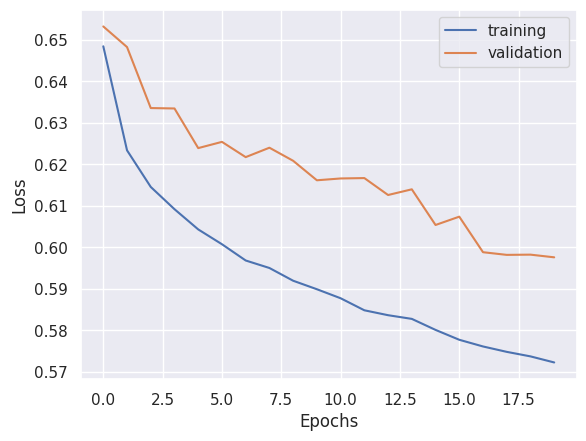

In [ ]:
# plot the accuracy vs val_accuracy
print(history.history.keys())

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['training', 'validation'])
plt.show()

In [ ]:
# !rm -rf ./Power_consumption